# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE AUTO USADO EN EUROPA
## DATASET: https://www.kaggle.com/datasets/alemazz11/cars-europe

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('/content/cars_cleaned.csv')
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,500,Compact,30000,17300,2022.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,14574,21900,2020.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,White,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,500,Sedan,138597,8990,2009.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500C,Convertible,46500,17990,2019.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,600e,Sedan,595,32950,2025.0,DE,Used,Electric,7.0,...,5.0,5.0,4.0,Orange,Cloth,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7629,Volvo,XC40,Off-Road/Pick-up,35295,31950,2023.0,BE,Used,Electric,7.0,...,5.0,5.0,5.0,Black,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7630,Volvo,V60,Station wagon,141565,13450,2015.0,NL,Used,Gasoline,7.0,...,4.0,5.0,5.0,Blue,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7631,Volvo,V60,Station wagon,93769,22900,2020.0,IT,Used,Diesel,7.0,...,5.0,5.0,4.0,Grey,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7632,Volvo,XC40,Off-Road/Pick-up,87055,22090,2021.0,ES,Used,Electric/Gasoline,7.0,...,5.0,5.0,5.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [ ]:
df['Price'] = df['Price'] / 1000
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,500,Compact,30000,17.30,2022.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,14574,21.90,2020.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,White,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,500,Sedan,138597,8.99,2009.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500C,Convertible,46500,17.99,2019.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,600e,Sedan,595,32.95,2025.0,DE,Used,Electric,7.0,...,5.0,5.0,4.0,Orange,Cloth,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7629,Volvo,XC40,Off-Road/Pick-up,35295,31.95,2023.0,BE,Used,Electric,7.0,...,5.0,5.0,5.0,Black,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7630,Volvo,V60,Station wagon,141565,13.45,2015.0,NL,Used,Gasoline,7.0,...,4.0,5.0,5.0,Blue,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7631,Volvo,V60,Station wagon,93769,22.90,2020.0,IT,Used,Diesel,7.0,...,5.0,5.0,4.0,Grey,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7632,Volvo,XC40,Off-Road/Pick-up,87055,22.09,2021.0,ES,Used,Electric/Gasoline,7.0,...,5.0,5.0,5.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


# SELECCIONAMOS COLUMNAS A UTILIZAR

In [4]:
df.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url'],
      dtype='object')

In [5]:
df = df[df['Condition'] == 'Used']
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,500,Compact,30000,17300,2022.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,14574,21900,2020.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,White,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,500,Sedan,138597,8990,2009.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500C,Convertible,46500,17990,2019.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,600e,Sedan,595,32950,2025.0,DE,Used,Electric,7.0,...,5.0,5.0,4.0,Orange,Cloth,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7629,Volvo,XC40,Off-Road/Pick-up,35295,31950,2023.0,BE,Used,Electric,7.0,...,5.0,5.0,5.0,Black,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7630,Volvo,V60,Station wagon,141565,13450,2015.0,NL,Used,Gasoline,7.0,...,4.0,5.0,5.0,Blue,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7631,Volvo,V60,Station wagon,93769,22900,2020.0,IT,Used,Diesel,7.0,...,5.0,5.0,4.0,Grey,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7632,Volvo,XC40,Off-Road/Pick-up,87055,22090,2021.0,ES,Used,Electric/Gasoline,7.0,...,5.0,5.0,5.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [7]:
df = df[['Mileage_km', 'Price', 'Year', 'Fuel_Type', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders']]

In [8]:
df

,Mileage_km,Price,Year,Fuel_Type,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders
0,30000,17300,2022.0,Gasoline,Manual,6.0,145,1398.0,5.0
1,14574,21900,2020.0,Gasoline,Manual,6.0,145,1368.0,5.0
2,138597,8990,2009.0,Gasoline,Manual,6.0,136,2275.0,5.0
3,46500,17990,2019.0,Gasoline,Manual,6.0,166,2275.0,5.0
4,595,32950,2025.0,Electric,Automatic,6.0,237,2275.0,5.0
...,...,...,...,...,...,...,...,...,...
7629,35295,31950,2023.0,Electric,Automatic,6.0,231,2275.0,5.0
7630,141565,13450,2015.0,Gasoline,Automatic,6.0,150,1596.0,4.0
7631,93769,22900,2020.0,Diesel,Automatic,6.0,190,2275.0,5.0
7632,87055,22090,2021.0,Electric/Gasoline,Automatic,6.0,212,2275.0,5.0


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [9]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['Fuel_Type', 'Gearbox'], dtype='object')

In [10]:
df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Gasoline' if x == 'Gasoline' else 'Other')
print(df['Fuel_Type'].value_counts())

Fuel_Type
Gasoline    3659
Other       3593
Name: count, dtype: int64


## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [11]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Fuel_Type
Gasoline    3659
Other       3593
Name: count, dtype: int64
**************************************************
Gearbox
Automatic         3879
Manual            3336
Semi-automatic      37
Name: count, dtype: int64


In [12]:
ordinal_cols = ['Fuel_Type']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['Fuel_Type'] ['Gearbox']


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [13]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [14]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['Fuel_Type']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Gearbox'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [15]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__Fuel_Type,onehotencoder__Gearbox_Automatic,onehotencoder__Gearbox_Manual,onehotencoder__Gearbox_Semi-automatic,remainder__Mileage_km,remainder__Price,remainder__Year,remainder__Gears,remainder__Power_hp,remainder__Engine_Size_cc,remainder__Cylinders
0,0.0,0.0,1.0,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0
1,0.0,0.0,1.0,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0
2,0.0,0.0,1.0,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0
3,0.0,0.0,1.0,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0
4,1.0,1.0,0.0,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
7629,1.0,1.0,0.0,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0
7630,0.0,1.0,0.0,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0
7631,1.0,1.0,0.0,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0
7632,1.0,1.0,0.0,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0


In [16]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Fuel_Type,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Gears,Power_hp,Engine_Size_cc,Cylinders
0,0.0,0.0,1.0,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0
1,0.0,0.0,1.0,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0
2,0.0,0.0,1.0,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0
3,0.0,0.0,1.0,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0
4,1.0,1.0,0.0,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
7629,1.0,1.0,0.0,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0
7630,0.0,1.0,0.0,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0
7631,1.0,1.0,0.0,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0
7632,1.0,1.0,0.0,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0


In [17]:
data_transformed_df.dtypes

,0
Fuel_Type,float64
Gearbox_Automatic,float64
Gearbox_Manual,float64
Gearbox_Semi-automatic,float64
Mileage_km,float64
Price,float64
Year,float64
Gears,float64
Power_hp,float64
Engine_Size_cc,float64


In [18]:
data_transformed_df

,Fuel_Type,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Gears,Power_hp,Engine_Size_cc,Cylinders
0,0.0,0.0,1.0,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0
1,0.0,0.0,1.0,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0
2,0.0,0.0,1.0,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0
3,0.0,0.0,1.0,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0
4,1.0,1.0,0.0,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
7629,1.0,1.0,0.0,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0
7630,0.0,1.0,0.0,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0
7631,1.0,1.0,0.0,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0
7632,1.0,1.0,0.0,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0


In [19]:
data_transformed_df.to_csv('cars_transformed.csv',index=None)

In [20]:
data_transformed_df = pd.read_csv('/content/cars_transformed.csv')
data_transformed_df

,Fuel_Type,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Gears,Power_hp,Engine_Size_cc,Cylinders
0,0.0,0.0,1.0,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0
1,0.0,0.0,1.0,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0
2,0.0,0.0,1.0,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0
3,0.0,0.0,1.0,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0
4,1.0,1.0,0.0,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
7247,1.0,1.0,0.0,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0
7248,0.0,1.0,0.0,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0
7249,1.0,1.0,0.0,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0
7250,1.0,1.0,0.0,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0


# PASO 5 - CORRELACIONES

In [21]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Year,0.643216
Power_hp,0.537559
Gearbox_Automatic,0.507086
Fuel_Type,0.337348
Engine_Size_cc,0.289684
Cylinders,0.147435
Gearbox_Semi-automatic,0.034684
Gearbox_Manual,-0.512434
Mileage_km,-0.568390


<Axes: >

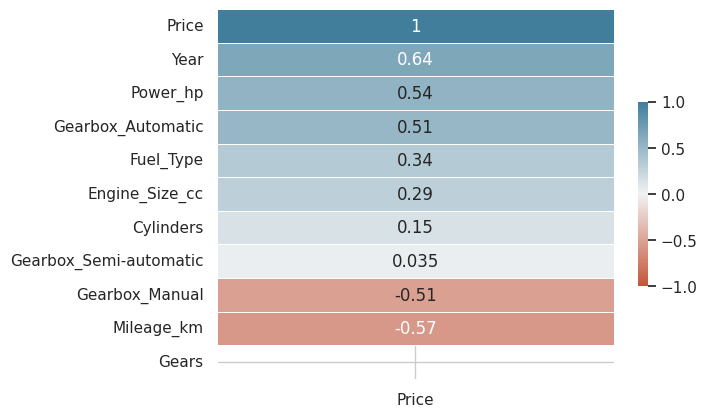

In [22]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividmos en train test

In [23]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols.remove('Gears')
cols

['Fuel_Type',
 'Gearbox_Automatic',
 'Gearbox_Manual',
 'Gearbox_Semi-automatic',
 'Mileage_km',
 'Year',
 'Power_hp',
 'Engine_Size_cc',
 'Cylinders']

In [24]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [26]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

## 2 - ESCALAMIENTO DE DATOS

In [27]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [29]:
results = {}
for name,model in models.items():

  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [30]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.726312,0.268719,0.385020
Lasso,0.700430,0.294131,0.407631
Ridge,0.726314,0.268718,0.385013
KNN Regressor,0.777771,0.218195,0.336540
SVR,0.775163,0.220755,0.336560
Random Forest Regressor,0.821234,0.175521,0.299669


# BUSCAMOS EL MEJOR MODELO

In [31]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8212)
Best model based on MSE: Random Forest Regressor (MSE: 0.18)


# GRAFICAMOS RESULTADOS

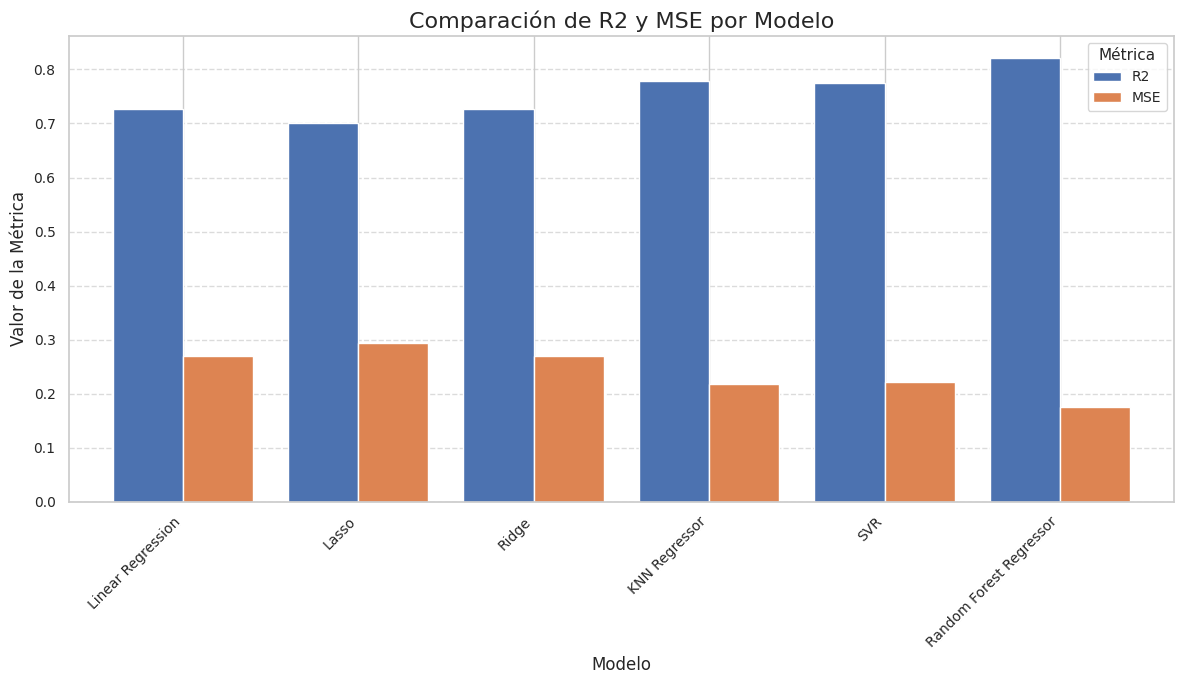

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()

# GUARDAMOS EL MEJOR MODELO Y SUS SCALERS

In [33]:
import joblib

# Get the best model (Random Forest Regressor in this case)
best_model_name = best_r2_model # From previous cell output
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'model.pkl')

# Save the scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print(f"Best model ({best_model_name}) saved as model.pkl")
print("Scaler_X saved as scaler_X.pkl")
print("Scaler_y saved as scaler_y.pkl")

Best model (Random Forest Regressor) saved as model.pkl
Scaler_X saved as scaler_X.pkl
Scaler_y saved as scaler_y.pkl


# CARGAMOS EL MEJOR MODELO Y SUS SCALERS

In [34]:
import joblib

# Load the best model
model = joblib.load('model.pkl')

# Load the scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

print("Model and scalers loaded successfully!")

Model and scalers loaded successfully!


In [35]:
def predict_new_car_price(
    fuel_type_input: str,
    gearbox_input: str,
    mileage_km: float,
    year: float,
    power_hp: float,
    engine_size_cc: float,
    cylinders: float
) -> float:
    """
    Predicts the price of a car based on new input data.

    Args:
        fuel_type_input (str): Fuel type ('gasolina' or 'other').
        gearbox_input (str): Gearbox type ('automatic', 'manual', or 'semi-automatic').
        mileage_km (float): Mileage in kilometers.
        year (float): Manufacturing year.
        power_hp (float): Horsepower.
        engine_size_cc (float): Engine size in cubic centimeters.
        cylinders (float): Number of cylinders.

    Returns:
        float: Predicted price of the car.
    """

    # Encode Fuel_Type (0.0 for 'gasolina', 1.0 for 'other')
    encoded_fuel_type = 0.0 if fuel_type_input.lower() == 'gasolina' else 1.0

    # Encode Gearbox (one-hot encoding)
    gearbox_automatic = 0.0
    gearbox_manual = 0.0
    gearbox_semi_automatic = 0.0

    if gearbox_input.lower() == 'automatico':
        gearbox_automatic = 1.0
    elif gearbox_input.lower() == 'manual':
        gearbox_manual = 1.0
    elif gearbox_input.lower() == 'semi-automatico':
        gearbox_semi_automatic = 1.0
    else:
        raise ValueError("Invalid gearbox_input. Must be 'automatic', 'manual', or 'semi-automatic'.")

    # Create the input array in the correct order
    # The order of columns was: ['Fuel_Type', 'Gearbox_Automatic', 'Gearbox_Manual',
    # 'Gearbox_Semi-automatic', 'Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Cylinders']
    new_data = np.array([[encoded_fuel_type,
                          gearbox_automatic,
                          gearbox_manual,
                          gearbox_semi_automatic,
                          mileage_km,
                          year,
                          power_hp,
                          engine_size_cc,
                          cylinders]])

    # Scale the new data using the loaded scaler_X
    new_data_scaled = scaler_X.transform(new_data)

    # Make a prediction using the loaded model
    prediction_scaled = model.predict(new_data_scaled)

    # Inverse transform the prediction to get the original price scale
    predicted_price = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]

    return predicted_price

# Example usage:
# new_car_features = {
#     'fuel_type_input': 'gasolina',
#     'gearbox_input': 'manual',
#     'mileage_km': 50000.0,
#     'year': 2018.0,
#     'power_hp': 150.0,
#     'engine_size_cc': 1600.0,
#     'cylinders': 4.0
# }

# predicted = predict_new_car_price(**new_car_features)
# print(f"Predicted price: {predicted:.2f} Euros")

In [36]:
# Example usage:
new_car_features = {
'fuel_type_input': 'gasolina',
'gearbox_input': 'manual',
'mileage_km': 50000.0,
'year': 2018.0,
'power_hp': 150.0,
'engine_size_cc': 1600.0,
'cylinders': 4.0
}

predicted = predict_new_car_price(**new_car_features)
print(f"Predicted price: {predicted:.2f} Euros")

Predicted price: 17199.07 Euros
